# Feature Engineering — Stage 5

The engineered-feature classifier. Loads the 13-feature anchor set from
[Stage 3](../plan/07_findings.md#2026-05-17--stage3-radars-ratios-auroc),
trains XGBoost + Logistic Regression under both protocols, and compares
against existing baselines (PLS-DA solo, vanilla CNN, DANN 5-seed soft-vote).

**Pre-registered in** [`plan/08 §2026-05-17 Stage 5`](../plan/08_expectations.md).
**Success bar:** LOSO mean parent-class recall ≥ 0.55 (interpretability parity
with PLS-DA solo's 0.603).

**Feature set (13 columns):**

| Group | Features |
|---|---|
| Empirical anchors (Stage 1–2) | `auc_lps_1050`, `auc_lps_1117`, `auc_lps_1194` |
| AA single bands + lipid_1080 (Stage 3 top AUROC) | `auc_aa_1004`, `auc_aa_1176`, `auc_aa_1617`, `auc_lipid_1080` |
| Best supporting ratios | `ratio_lipid_over_protein`, `ratio_lps_1117_over_1050`, `ratio_lps_1194_over_1050` |
| Literature triple (negative-finding writeup) | `auc_na_1338`, `auc_lipid_1454`, `auc_amide_i_1658` |

**Notebook structure:**

| § | What |
|---|---|
| A | Setup + load |
| B | Feature engineering — distribution, correlation, per-class statistics |
| C | Eval helper (uses `atlas.evaluate.evaluate_fold` for direct comparability with baselines) |
| D | Protocol A — StratifiedGroupKFold(5), 5 folds × 3 models |
| E | Protocol B — LOSO, 9 folds × 3 models |
| F | Per-strain breakdown + per-strain best-model table |
| G | Summary table + verdict against plan/08 pre-reg |


In [1]:
import sys
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import warnings

warnings.filterwarnings("ignore")

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from atlas.io import load_cache
from atlas.evaluate import evaluate_fold, PRIMARY_CLASSES, aggregate

CACHE = REPO / "data_cache"
OUT = REPO / "outputs" / "band_chemistry" / "stage5"
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"

CLASS_ORDER = ["STEC", "Non-STEC", "Salmonella", "H2O"]
CLASS_COLORS = {"STEC": "#d62728", "Non-STEC": "#1f77b4",
                "Salmonella": "#2ca02c", "H2O": "#7f7f7f"}
SUBCLASS_COLORS = {
    "O103H2": "#d62728", "O121H19": "#e7665a", "O157H7": "#a02124",
    "83972": "#1f77b4", "ATCC25922": "#5fa6d8", "K-12": "#114573",
    "Dublin": "#2ca02c", "Heidelburg": "#73c073", "Typhimurium": "#175f17",
    "H2O": "#7f7f7f",
}

ANCHOR_FEATURES = [
    # Empirical anchors
    "auc_lps_1050", "auc_lps_1117", "auc_lps_1194",
    # Stage 3 top-AUROC single bands
    "auc_aa_1004", "auc_aa_1176", "auc_aa_1617", "auc_lipid_1080",
    # Supporting ratios
    "ratio_lipid_over_protein", "ratio_lps_1117_over_1050", "ratio_lps_1194_over_1050",
    # Literature triple
    "auc_na_1338", "auc_lipid_1454", "auc_amide_i_1658",
]
print(f"feature set: {len(ANCHOR_FEATURES)} features")


feature set: 13 features


In [2]:
# Load data
spec_df, _X, _wn, meta = load_cache(CACHE)
qc = np.load(CACHE / "qc_mask.npy")
spec_df = spec_df.reset_index(drop=True)
spec_df_qc = spec_df[qc].reset_index(drop=True)

feat = pd.read_parquet(CACHE / "band_features.parquet")
feat = feat.reset_index(drop=True)

# Build mapping pre-QC row index → post-QC row index
qc_to_post = np.full(len(qc), -1, dtype=np.int64)
qc_to_post[qc] = np.arange(int(qc.sum()))

# Labels (post-QC)
y_post = spec_df_qc["primary_class"].values
file_ids_post = spec_df_qc["file_id"].values
sub_post = spec_df_qc["subclass"].fillna("H2O").values

# Feature matrix
X_feat = feat[ANCHOR_FEATURES].values.astype(np.float64)
print(f"feature matrix: {X_feat.shape}  dtype={X_feat.dtype}")
print(f"any NaN? {np.isnan(X_feat).any()}  any inf? {np.isinf(X_feat).any()}")
print(f"labels    : {np.unique(y_post, return_counts=True)}")


feature matrix: (7122, 13)  dtype=float64
any NaN? False  any inf? False
labels    : (array(['H2O', 'Non-STEC', 'STEC', 'Salmonella'], dtype=object), array([ 684, 1908, 2263, 2267]))


## §B — Feature engineering inspection

Sanity checks on the 13-feature anchor set before we train. Three things to
look at:

1. **Per-feature distribution by class** (do features separate visually?)
2. **Inter-feature correlation** (redundancy → reduce if highly correlated)
3. **Per-class means + SDs** (numerical summary)


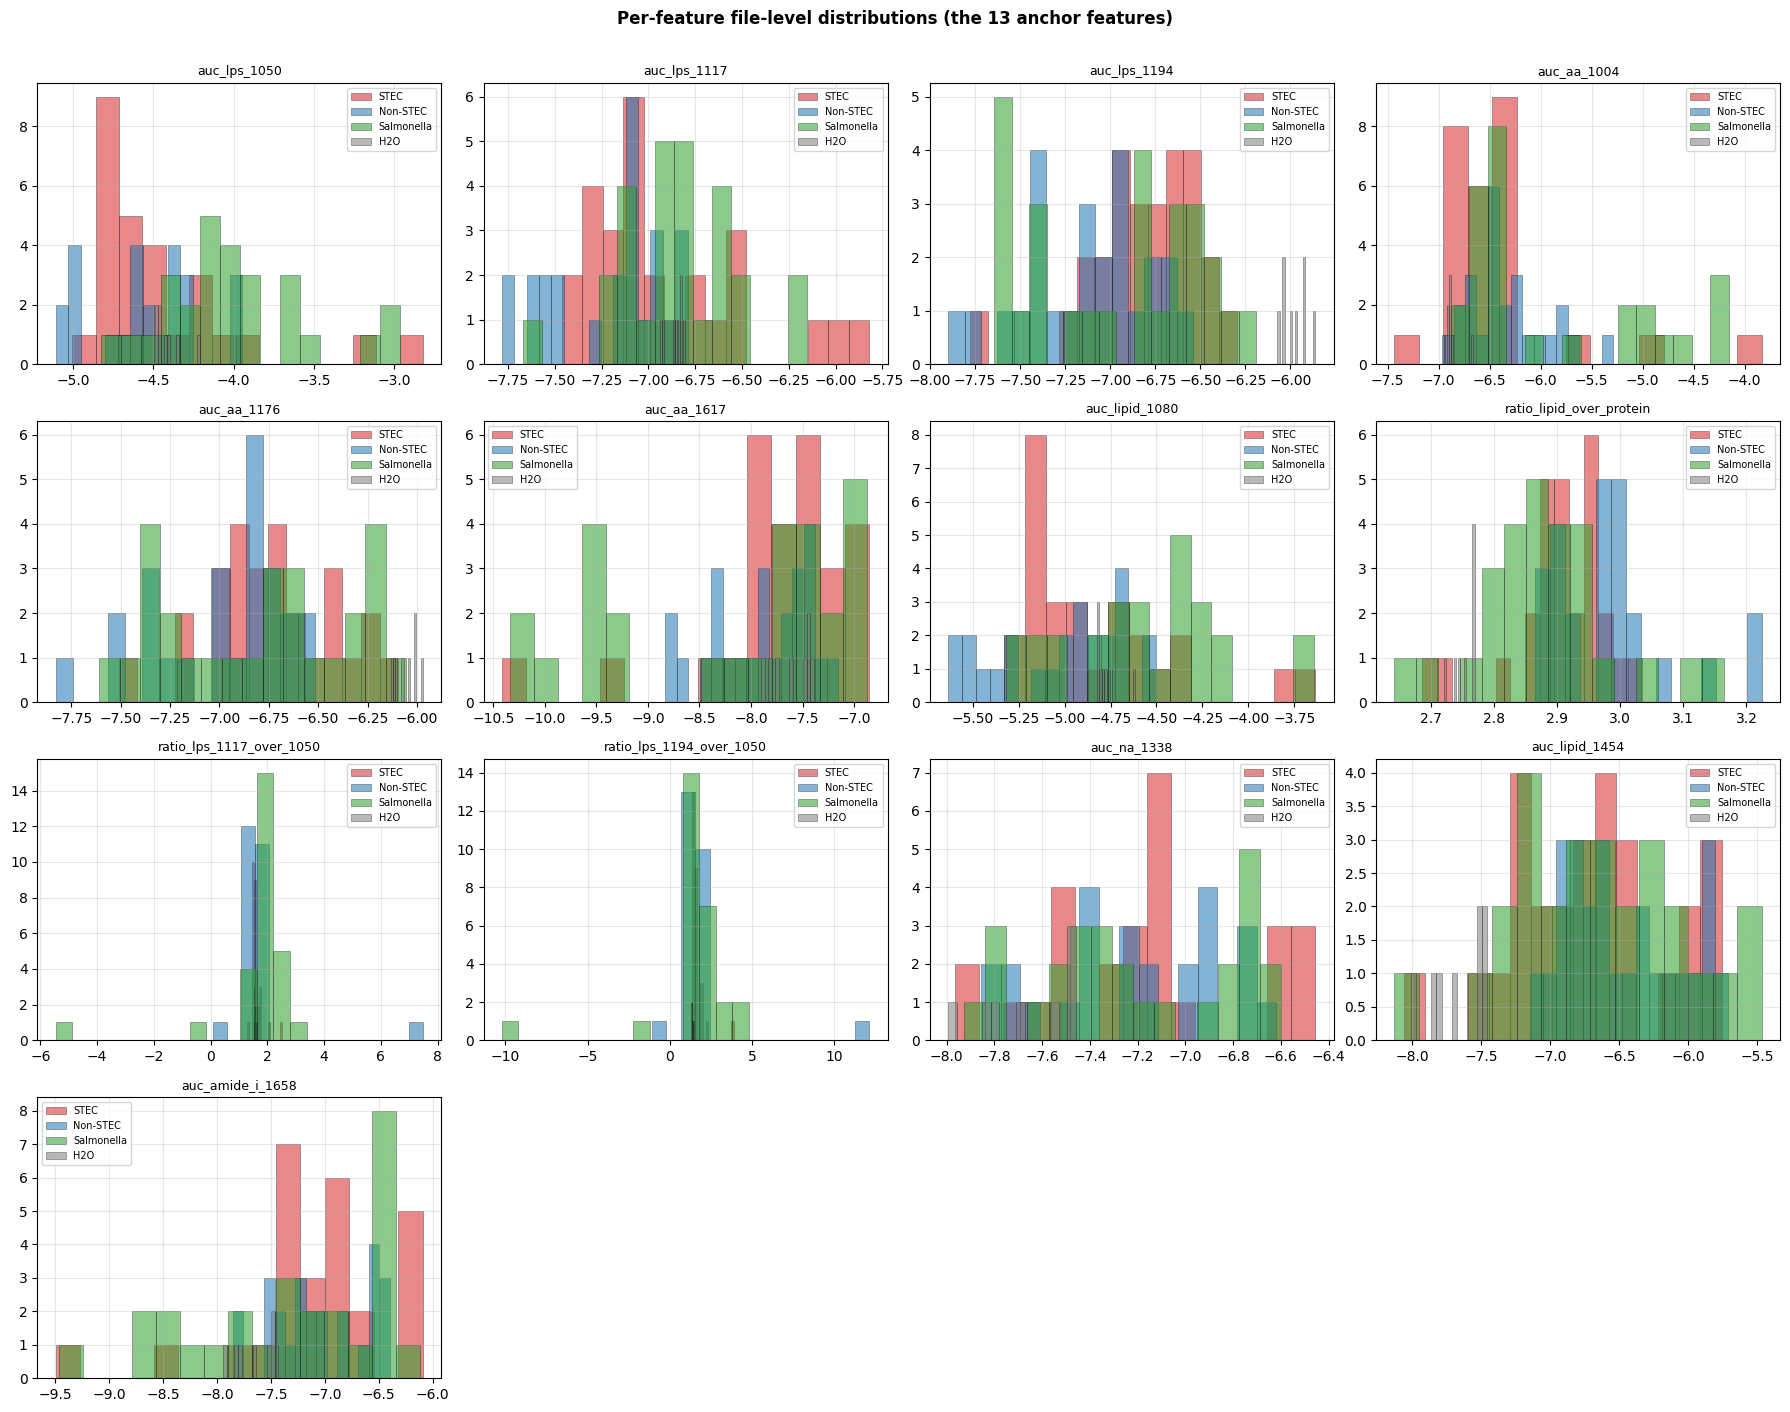

In [3]:
# B1 — Per-feature distribution per primary class (file-level)
file_level = pd.DataFrame({
    "primary_class": pd.Series(spec_df_qc["primary_class"].values).values,
    "file_id": file_ids_post,
})
for c in ANCHOR_FEATURES:
    file_level[c] = feat[c].values

file_means = file_level.groupby("file_id").agg(
    {**{c: "mean" for c in ANCHOR_FEATURES}, "primary_class": "first"}
)

n_features = len(ANCHOR_FEATURES)
ncols = 4
nrows = (n_features + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows))
axes = axes.flat
for ax, col in zip(axes, ANCHOR_FEATURES):
    for c in CLASS_ORDER:
        vals = file_means.loc[file_means["primary_class"] == c, col].values
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=15, alpha=0.55, color=CLASS_COLORS[c],
                label=c, edgecolor="black", lw=0.4)
    ax.set_title(col, fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
for ax in axes[n_features:]:
    ax.set_visible(False)
fig.suptitle("Per-feature file-level distributions (the 13 anchor features)",
             fontsize=12, y=1.005, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "01_feature_distributions.png", bbox_inches="tight")
plt.show()


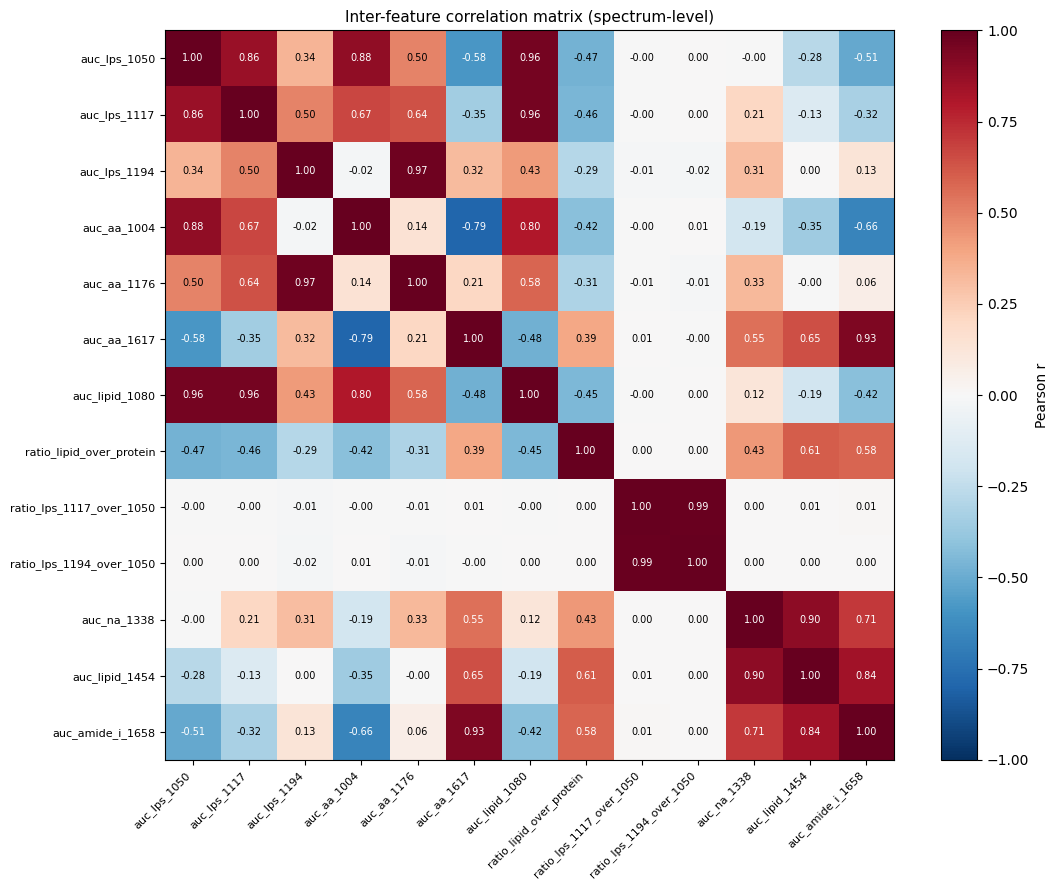

\nHighly correlated pairs (|r| > 0.85):
  r=+0.865  auc_lps_1050                   ↔ auc_lps_1117
  r=+0.884  auc_lps_1050                   ↔ auc_aa_1004
  r=+0.959  auc_lps_1050                   ↔ auc_lipid_1080
  r=+0.956  auc_lps_1117                   ↔ auc_lipid_1080
  r=+0.974  auc_lps_1194                   ↔ auc_aa_1176
  r=+0.930  auc_aa_1617                    ↔ auc_amide_i_1658
  r=+0.991  ratio_lps_1117_over_1050       ↔ ratio_lps_1194_over_1050
  r=+0.895  auc_na_1338                    ↔ auc_lipid_1454


In [4]:
# B2 — Inter-feature correlation matrix
corr = feat[ANCHOR_FEATURES].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ANCHOR_FEATURES)))
ax.set_yticks(range(len(ANCHOR_FEATURES)))
ax.set_xticklabels(ANCHOR_FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ANCHOR_FEATURES, fontsize=8)
for i in range(len(ANCHOR_FEATURES)):
    for j in range(len(ANCHOR_FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.045, label="Pearson r")
ax.set_title("Inter-feature correlation matrix (spectrum-level)", fontsize=11)
plt.tight_layout()
plt.savefig(OUT / "02_feature_correlation.png", bbox_inches="tight")
plt.show()

# Pairs with |r| > 0.85 — candidates for elimination
print("\\nHighly correlated pairs (|r| > 0.85):")
for i in range(len(ANCHOR_FEATURES)):
    for j in range(i + 1, len(ANCHOR_FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  r={r:+.3f}  {ANCHOR_FEATURES[i]:30s} ↔ {ANCHOR_FEATURES[j]}")


## §C — Evaluation helper

Reuse `atlas.evaluate.evaluate_fold` for direct comparability with all existing
baselines. Returns `FoldResult` with spectrum-level + file-level metrics,
per-class recalls, per-subclass recalls, Brier scores, reliability curves —
all the things the classical / CNN / DANN baselines also report.

Per-fold pipeline:
1. Map pre-QC row indices → post-QC row indices (split files are pre-QC, our
   feature cache is post-QC).
2. StandardScaler fit on train, apply to test.
3. Fit model on train, predict_proba on test.
4. Call `evaluate_fold` for metrics.


In [5]:
def make_xgb(seed):
    return xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.08,
        subsample=0.85, colsample_bytree=0.85,
        objective="multi:softprob", random_state=seed,
        n_jobs=4, eval_metric="mlogloss",
        tree_method="hist", verbosity=0,
    )

def make_logreg(seed):
    return LogisticRegression(
        max_iter=2000, C=1.0, multi_class="multinomial",
        solver="lbfgs", random_state=seed,
    )

LABEL_INDEX = {c: i for i, c in enumerate(PRIMARY_CLASSES)}
INDEX_TO_LABEL = np.array(PRIMARY_CLASSES)


def run_fold(model_factory, fold, model_name, fold_seed=42, run_dir=None):
    train_pre = np.asarray(fold["train_row_indices"], dtype=np.int64)
    test_pre  = np.asarray(fold["test_row_indices"], dtype=np.int64)
    train_post = qc_to_post[train_pre]
    test_post  = qc_to_post[test_pre]
    assert (train_post >= 0).all(), "train row not QC-passing"
    assert (test_post >= 0).all(),  "test row not QC-passing"

    X_train = X_feat[train_post]
    X_test  = X_feat[test_post]
    y_train_str = y_post[train_post]
    y_test_str  = y_post[test_post]

    # Standardize
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)

    # Encode labels to integers (XGB expects ints; LogReg can take strings but ints are fine)
    y_train_int = np.array([LABEL_INDEX[c] for c in y_train_str])

    # Train
    t0 = time.perf_counter()
    model = model_factory(fold_seed)
    model.fit(X_train, y_train_int)
    train_dt = time.perf_counter() - t0

    # Predict
    proba = model.predict_proba(X_test)
    # If model returns probabilities in arbitrary class order (LogReg uses classes_)
    if hasattr(model, "classes_"):
        # Align to PRIMARY_CLASSES order
        class_perm = np.array([np.where(model.classes_ == LABEL_INDEX[c])[0][0]
                               for c in PRIMARY_CLASSES])
        proba = proba[:, class_perm]

    fr = evaluate_fold(
        fold_id=fold["fold"],
        protocol=fold.get("_protocol", "unknown"),
        model_name=model_name,
        y_true=y_test_str,
        y_proba=proba,
        file_ids=file_ids_post[test_post],
        subclass=sub_post[test_post],
        n_train=int(train_post.size),
        n_train_files=int(len(set(file_ids_post[train_post]))),
        n_test_files=int(len(set(file_ids_post[test_post]))),
        training_time_s=train_dt,
        best_hyperparams=None,
    )
    return fr, proba


def run_protocol(splits_path, model_factory, model_name, fold_seed=42):
    splits = json.load(splits_path.open())
    folds = splits["folds"]
    for f in folds:
        f["_protocol"] = splits["protocol"]
    results = []
    for f in folds:
        fr, _ = run_fold(model_factory, f, model_name, fold_seed=fold_seed)
        results.append(fr)
        print(f"  fold={str(f['fold']):>14}  "
              f"spec_F1={fr.spectrum_macro_f1:.3f}  "
              f"file_F1={fr.file_macro_f1:.3f}  "
              f"file_bacc={fr.file_balanced_acc:.3f}")
    return results


def fold_summary(results, model_name, protocol):
    mr = aggregate(results, model_name=model_name, protocol=protocol)
    return mr


## §D — Protocol A run (StratifiedGroupKFold-5)

5 folds × 3 models (XGBoost, LogReg, soft-vote ensemble).

In [6]:
splits_a_path = CACHE / "splits" / "protocol_a.json"
print(f"Protocol A — XGBoost")
xgb_a = run_protocol(splits_a_path, make_xgb, "band_xgb_a")
mr_xgb_a = fold_summary(xgb_a, "band_xgb_a", "group_kfold")
print(f"  -> mean file_macro_f1 = {mr_xgb_a.file_macro_f1_mean:.3f} ± {mr_xgb_a.file_macro_f1_sd:.3f}")
print(f"  -> mean file_balanced_acc = {np.mean([f.file_balanced_acc for f in xgb_a]):.3f}")

print(f"\\nProtocol A — LogReg")
lr_a = run_protocol(splits_a_path, make_logreg, "band_logreg_a")
mr_lr_a = fold_summary(lr_a, "band_logreg_a", "group_kfold")
print(f"  -> mean file_macro_f1 = {mr_lr_a.file_macro_f1_mean:.3f} ± {mr_lr_a.file_macro_f1_sd:.3f}")
print(f"  -> mean file_balanced_acc = {np.mean([f.file_balanced_acc for f in lr_a]):.3f}")


Protocol A — XGBoost


  fold=             0  spec_F1=0.532  file_F1=0.809  file_bacc=0.783


  fold=             1  spec_F1=0.490  file_F1=0.695  file_bacc=0.688


  fold=             2  spec_F1=0.613  file_F1=1.000  file_bacc=1.000


  fold=             3  spec_F1=0.541  file_F1=0.899  file_bacc=0.908


  fold=             4  spec_F1=0.580  file_F1=0.945  file_bacc=0.938
  -> mean file_macro_f1 = 0.870 ± 0.120
  -> mean file_balanced_acc = 0.863
\nProtocol A — LogReg
  fold=             0  spec_F1=0.484  file_F1=0.571  file_bacc=0.558


  fold=             1  spec_F1=0.487  file_F1=0.717  file_bacc=0.729
  fold=             2  spec_F1=0.484  file_F1=0.651  file_bacc=0.633


  fold=             3  spec_F1=0.355  file_F1=0.692  file_bacc=0.733
  fold=             4  spec_F1=0.494  file_F1=0.765  file_bacc=0.792
  -> mean file_macro_f1 = 0.679 ± 0.073
  -> mean file_balanced_acc = 0.689


In [7]:
# Soft-vote ensemble (XGBoost + LogReg, per fold) - protocol A
splits_a = json.load(splits_a_path.open())
ens_a = []
for f in splits_a["folds"]:
    f["_protocol"] = splits_a["protocol"]
    fr_xgb, p_xgb = run_fold(make_xgb, f, "ens_a", fold_seed=42)
    fr_lr,  p_lr  = run_fold(make_logreg, f, "ens_a", fold_seed=42)
    proba_ens = 0.5 * (p_xgb + p_lr)
    test_pre = np.asarray(f["test_row_indices"], dtype=np.int64)
    test_post = qc_to_post[test_pre]
    fr = evaluate_fold(
        fold_id=f["fold"], protocol="group_kfold", model_name="band_ens_a",
        y_true=y_post[test_post], y_proba=proba_ens,
        file_ids=file_ids_post[test_post], subclass=sub_post[test_post],
        n_train=fr_xgb.n_train, n_train_files=fr_xgb.n_train_files,
        n_test_files=fr_xgb.n_test_files, training_time_s=0.0,
    )
    ens_a.append(fr)
    print(f"  fold={str(f['fold']):>14}  file_F1={fr.file_macro_f1:.3f}")
mr_ens_a = fold_summary(ens_a, "band_ens_a", "group_kfold")
print(f"\\nProtocol A — Ensemble (XGB + LogReg soft-vote)")
print(f"  mean file_macro_f1 = {mr_ens_a.file_macro_f1_mean:.3f} ± {mr_ens_a.file_macro_f1_sd:.3f}")


  fold=             0  file_F1=0.859


  fold=             1  file_F1=0.695


  fold=             2  file_F1=0.859


  fold=             3  file_F1=0.854


  fold=             4  file_F1=0.914
\nProtocol A — Ensemble (XGB + LogReg soft-vote)
  mean file_macro_f1 = 0.836 ± 0.083


## §E — Protocol B (LOSO) run

9 folds × 3 models. **The honest cross-strain test** — each fold holds out
an entire bacterial subclass.

The headline metric for LOSO is per-strain parent-class recall, averaged
across the 9 strains. Macro-F1 isn't useful on LOSO because each fold has
only one class in test (3 of 4 class F1s are 0 by construction).

In [8]:
splits_b_path = CACHE / "splits" / "protocol_b.json"
print(f"Protocol B — XGBoost (LOSO)")
xgb_b = run_protocol(splits_b_path, make_xgb, "band_xgb_b")
mr_xgb_b = fold_summary(xgb_b, "band_xgb_b", "loso")
print(f"  -> per-strain parent-recall: see table below")

print(f"\\nProtocol B — LogReg (LOSO)")
lr_b = run_protocol(splits_b_path, make_logreg, "band_logreg_b")
mr_lr_b = fold_summary(lr_b, "band_logreg_b", "loso")

# Soft-vote ensemble
splits_b = json.load(splits_b_path.open())
ens_b = []
print(f"\\nProtocol B — Ensemble (XGB + LogReg soft-vote, LOSO)")
for f in splits_b["folds"]:
    f["_protocol"] = "loso"
    fr_xgb, p_xgb = run_fold(make_xgb, f, "ens_b", fold_seed=42)
    fr_lr,  p_lr  = run_fold(make_logreg, f, "ens_b", fold_seed=42)
    proba_ens = 0.5 * (p_xgb + p_lr)
    test_pre = np.asarray(f["test_row_indices"], dtype=np.int64)
    test_post = qc_to_post[test_pre]
    fr = evaluate_fold(
        fold_id=f["fold"], protocol="loso", model_name="band_ens_b",
        y_true=y_post[test_post], y_proba=proba_ens,
        file_ids=file_ids_post[test_post], subclass=sub_post[test_post],
        n_train=fr_xgb.n_train, n_train_files=fr_xgb.n_train_files,
        n_test_files=fr_xgb.n_test_files, training_time_s=0.0,
    )
    ens_b.append(fr)
    print(f"  fold={str(f['fold']):>14}  file_F1={fr.file_macro_f1:.3f}")
mr_ens_b = fold_summary(ens_b, "band_ens_b", "loso")


Protocol B — XGBoost (LOSO)


  fold=         83972  spec_F1=0.124  file_F1=0.100  file_bacc=0.250


  fold=     ATCC25922  spec_F1=0.070  file_F1=0.050  file_bacc=0.111


  fold=        Dublin  spec_F1=0.093  file_F1=0.091  file_bacc=0.222


  fold=    Heidelburg  spec_F1=0.118  file_F1=0.125  file_bacc=0.333


...

  fold=          K-12  file_F1=0.000


  fold=        O103H2  file_F1=0.179


  fold=       O121H19  file_F1=0.125


  fold=        O157H7  file_F1=0.000


  fold=   Typhimurium  file_F1=0.091


## §F — Per-strain breakdown

The honest LOSO summary: per-strain parent-class recall for each of the 3 models.
For each LOSO fold, we report how often the held-out strain's files get the
correct parent class.

In [9]:
def per_strain_recall(results):
    rows = []
    for fr in results:
        for sub_label, recall in fr.per_subclass_recall_file.items():
            if not np.isnan(recall) and sub_label != "H2O":
                rows.append({"fold": fr.fold_id, "strain": sub_label, "recall": recall})
    df = pd.DataFrame(rows)
    return df.groupby("strain")["recall"].first()

per_strain_xgb = per_strain_recall(xgb_b)
per_strain_lr  = per_strain_recall(lr_b)
per_strain_ens = per_strain_recall(ens_b)

# Existing baselines for comparison (from plan/07)
BASELINES = {
    "PLS-DA (raw 987 bins)":    {"O157H7": 0.00, "O121H19": 0.89, "O103H2": 0.78,
                                  "ATCC25922": 0.33, "K-12": 0.00, "83972": 0.875,
                                  "Typhimurium": 0.875, "Heidelburg": 0.78, "Dublin": 0.875,
                                  "MEAN": 0.603},
    "Vanilla CNN":               {"O157H7": 0.56, "O121H19": 0.00, "O103H2": 0.00,
                                  "ATCC25922": 0.11, "K-12": 0.50, "83972": 0.625,
                                  "Typhimurium": 0.625, "Heidelburg": 0.625, "Dublin": 0.50,
                                  "MEAN": 0.35},
    "DANN λ=0.3 (5-seed soft-vote)": {"O157H7": 0.78, "O121H19": 0.56, "O103H2": 0.89,
                                       "ATCC25922": 0.89, "K-12": 0.75, "83972": 0.25,
                                       "Typhimurium": 0.11, "Heidelburg": 0.11, "Dublin": 0.00,
                                       "MEAN": 0.484},  # approx (single-seed numbers)
}

# Build comparison table
all_strains = ["O157H7", "O121H19", "O103H2", "ATCC25922", "K-12", "83972",
               "Typhimurium", "Heidelburg", "Dublin"]
def to_dict(s):  return {strain: float(s.get(strain, np.nan)) for strain in all_strains}
results_table = pd.DataFrame({
    "PLS-DA": pd.Series(BASELINES["PLS-DA (raw 987 bins)"]),
    "vanilla CNN": pd.Series(BASELINES["Vanilla CNN"]),
    "DANN λ=0.3": pd.Series(BASELINES["DANN λ=0.3 (5-seed soft-vote)"]),
    "Band XGB": pd.Series(to_dict(per_strain_xgb) | {
        "MEAN": float(per_strain_xgb.mean())
    }),
    "Band LogReg": pd.Series(to_dict(per_strain_lr) | {
        "MEAN": float(per_strain_lr.mean())
    }),
    "Band Ensemble": pd.Series(to_dict(per_strain_ens) | {
        "MEAN": float(per_strain_ens.mean())
    }),
}).reindex(all_strains + ["MEAN"])

print("Per-strain LOSO parent-class recall:")
print(results_table.round(3).to_string())
results_table.round(4).to_csv(OUT / "03_per_strain_loso.csv")


Per-strain LOSO parent-class recall:
             PLS-DA  vanilla CNN  DANN λ=0.3  Band XGB  Band LogReg  Band Ensemble
O157H7        0.000        0.560       0.780     0.000        0.000          0.000
O121H19       0.890        0.000       0.560     0.889        0.000          0.333
O103H2        0.780        0.000       0.890     0.667        0.111          0.556
ATCC25922     0.330        0.110       0.890     0.111        0.000          0.000
K-12          0.000        0.500       0.750     0.000        0.000          0.000
83972         0.875        0.625       0.250     0.250        0.000          0.000
Typhimurium   0.875        0.625       0.110     0.333        0.222          0.222
Heidelburg    0.780        0.625       0.110     0.333        0.222          0.333
Dublin        0.875        0.500       0.000     0.222        0.111          0.111
MEAN          0.603        0.350       0.484     0.312        0.074          0.173


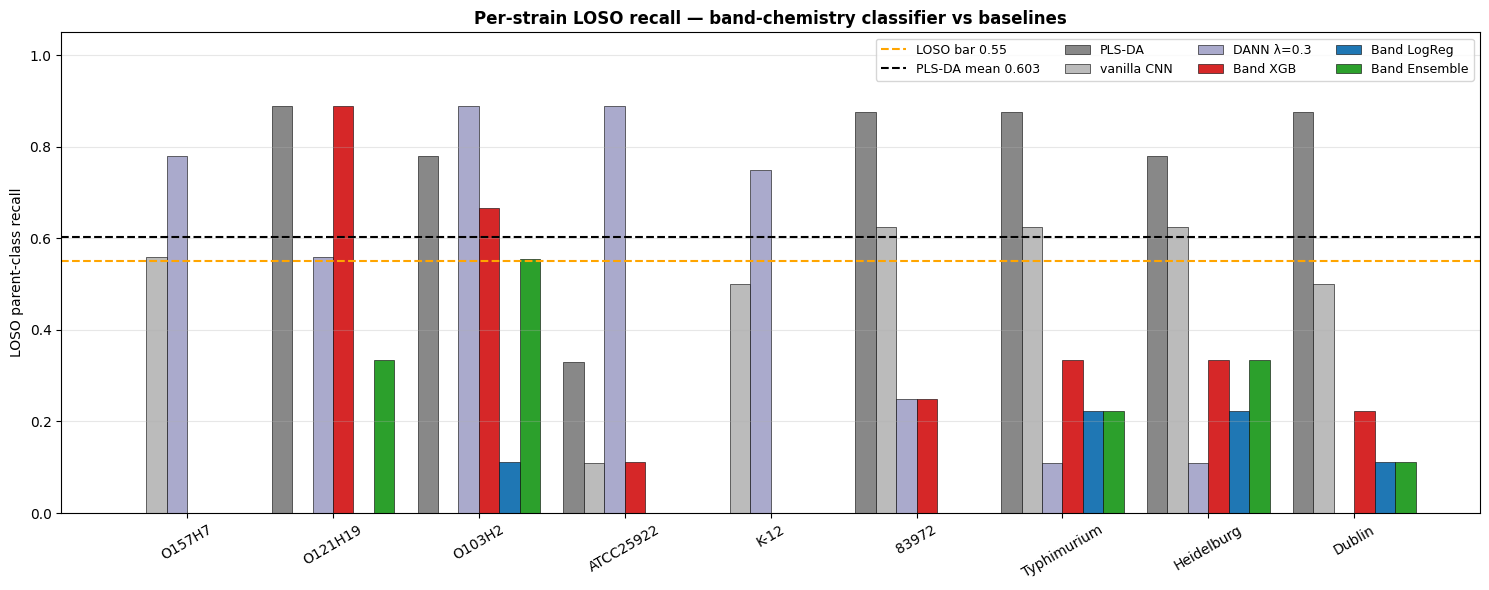

In [10]:
# Visualize per-strain
fig, ax = plt.subplots(figsize=(15, 6))
strains = all_strains
x = np.arange(len(strains))
width = 0.14
cols = ["PLS-DA", "vanilla CNN", "DANN λ=0.3", "Band XGB", "Band LogReg", "Band Ensemble"]
colors_models = {
    "PLS-DA":         "#888",
    "vanilla CNN":    "#bbb",
    "DANN λ=0.3":     "#aac",
    "Band XGB":       "#d62728",
    "Band LogReg":    "#1f77b4",
    "Band Ensemble":  "#2ca02c",
}

for i, col in enumerate(cols):
    vals = results_table.loc[strains, col].values
    ax.bar(x + (i - len(cols) / 2 + 0.5) * width, vals, width,
           color=colors_models[col], label=col, edgecolor="black", lw=0.4)

ax.axhline(0.55, color="orange", lw=1.5, ls="--", label="LOSO bar 0.55")
ax.axhline(0.603, color="black", lw=1.5, ls="--", label="PLS-DA mean 0.603")

ax.set_xticks(x)
ax.set_xticklabels(strains, rotation=30)
ax.set_ylabel("LOSO parent-class recall")
ax.set_title("Per-strain LOSO recall — band-chemistry classifier vs baselines",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, ncol=4)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT / "04_per_strain_comparison.png", bbox_inches="tight")
plt.show()


## §G — Summary + verdict against plan/08

The headline numbers + branching verdict from plan/08 Stage 5 pre-registration.

In [11]:
# Headline metrics
PROTOCOL_A_F1 = {
    "XGBoost":   mr_xgb_a.file_macro_f1_mean,
    "LogReg":    mr_lr_a.file_macro_f1_mean,
    "Ensemble":  mr_ens_a.file_macro_f1_mean,
}
LOSO_MEAN = {
    "XGBoost":   float(per_strain_xgb.mean()),
    "LogReg":    float(per_strain_lr.mean()),
    "Ensemble":  float(per_strain_ens.mean()),
}

print("=== Protocol A (file-level macro-F1, mean ± SD over 5 folds) ===")
for m, sd in [("XGBoost", mr_xgb_a.file_macro_f1_sd),
              ("LogReg",  mr_lr_a.file_macro_f1_sd),
              ("Ensemble", mr_ens_a.file_macro_f1_sd)]:
    print(f"  {m:10s}  {PROTOCOL_A_F1[m]:.3f} ± {sd:.3f}")

print("\\n=== Protocol B (LOSO mean parent-class recall over 9 strains) ===")
for m in ["XGBoost", "LogReg", "Ensemble"]:
    print(f"  {m:10s}  {LOSO_MEAN[m]:.3f}")

best_loso_mean = max(LOSO_MEAN.values())
best_model = [k for k, v in LOSO_MEAN.items() if v == best_loso_mean][0]
print(f"\\nBest LOSO model: {best_model} = {best_loso_mean:.3f}")

# Verdict per plan/08 branching
if best_loso_mean >= 0.55:
    verdict = "A"
    verdict_text = (f"PASS — interpretability parity ≥ 0.55 cleared. "
                    f"Engineered features ({len(ANCHOR_FEATURES)} features) reach "
                    f"LOSO {best_loso_mean:.3f} vs raw 987-bin PLS-DA's 0.603.")
elif best_loso_mean >= 0.45:
    verdict = "B"
    verdict_text = (f"PARTIAL — {best_loso_mean:.3f} below 0.55 bar but above vanilla "
                    f"CNN 0.35. Engineered features capture chemistry signal but not "
                    f"enough for cross-strain parity with PLS-DA solo.")
else:
    verdict = "C"
    verdict_text = (f"FAIL — engineered features at {best_loso_mean:.3f} below 0.45 floor. "
                    f"File-level signal at lps_1194 (d=+1.03) is strain-specific. "
                    f"Pivot writeup to LOSO-failure-via-strain-specificity story.")
print(f"\\n=== Verdict (plan/08 branching): ({verdict}) ===")
print(verdict_text)

# Save final summary
summary = {
    "stage": 5,
    "verdict_branch": verdict,
    "verdict_text": verdict_text,
    "n_features": len(ANCHOR_FEATURES),
    "feature_set": ANCHOR_FEATURES,
    "protocol_a_file_macro_f1": PROTOCOL_A_F1,
    "loso_mean_parent_recall": LOSO_MEAN,
    "per_strain_xgb": {s: float(per_strain_xgb.get(s, np.nan)) for s in all_strains},
    "per_strain_lr":  {s: float(per_strain_lr.get(s, np.nan)) for s in all_strains},
    "per_strain_ens": {s: float(per_strain_ens.get(s, np.nan)) for s in all_strains},
    "baselines_comparison": {
        "PLS-DA": 0.603,
        "vanilla_CNN": 0.35,
        "DANN_lam0p3_5seed": 0.448,
    },
}
with (OUT / "05_stage5_summary.json").open("w") as f:
    json.dump(summary, f, indent=2, default=float)
print(f"\\nwrote {OUT / '05_stage5_summary.json'}")


=== Protocol A (file-level macro-F1, mean ± SD over 5 folds) ===
  XGBoost     0.870 ± 0.120
  LogReg      0.679 ± 0.073
  Ensemble    0.836 ± 0.083
\n=== Protocol B (LOSO mean parent-class recall over 9 strains) ===
  XGBoost     0.312
  LogReg      0.074
  Ensemble    0.173
\nBest LOSO model: XGBoost = 0.312
\n=== Verdict (plan/08 branching): (C) ===
FAIL — engineered features at 0.312 below 0.45 floor. File-level signal at lps_1194 (d=+1.03) is strain-specific. Pivot writeup to LOSO-failure-via-strain-specificity story.
\nwrote /Users/devashishthapliyal/Documents/NomadX/outputs/band_chemistry/stage5/05_stage5_summary.json


In [12]:
# Final consolidated table for the writeup
final = pd.DataFrame({
    "Protocol A file-macro-F1": [
        f"{mr_xgb_a.file_macro_f1_mean:.3f} ± {mr_xgb_a.file_macro_f1_sd:.3f}",
        f"{mr_lr_a.file_macro_f1_mean:.3f} ± {mr_lr_a.file_macro_f1_sd:.3f}",
        f"{mr_ens_a.file_macro_f1_mean:.3f} ± {mr_ens_a.file_macro_f1_sd:.3f}",
    ],
    "LOSO mean parent-recall": [
        f"{LOSO_MEAN['XGBoost']:.3f}",
        f"{LOSO_MEAN['LogReg']:.3f}",
        f"{LOSO_MEAN['Ensemble']:.3f}",
    ],
}, index=["XGBoost (13 feats)", "LogReg (13 feats)", "Ensemble (XGB+LR)"])

baseline_row = pd.DataFrame({
    "Protocol A file-macro-F1": ["0.951 ± 0.051", "0.649 ± 0.079", "0.566 ± 0.091"],
    "LOSO mean parent-recall":  ["0.603",          "0.35",           "0.448"],
}, index=["PLS-DA (raw 987 bins)", "vanilla CNN", "DANN λ=0.3 5-seed"])

combined = pd.concat([final, baseline_row])
print("Stage 5 final comparison table:")
print(combined.to_string())
combined.to_csv(OUT / "06_final_comparison.csv")


Stage 5 final comparison table:
                      Protocol A file-macro-F1 LOSO mean parent-recall
XGBoost (13 feats)               0.870 ± 0.120                   0.312
LogReg (13 feats)                0.679 ± 0.073                   0.074
Ensemble (XGB+LR)                0.836 ± 0.083                   0.173
PLS-DA (raw 987 bins)            0.951 ± 0.051                   0.603
vanilla CNN                      0.649 ± 0.079                    0.35
DANN λ=0.3 5-seed                0.566 ± 0.091                   0.448
